In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB
0
76


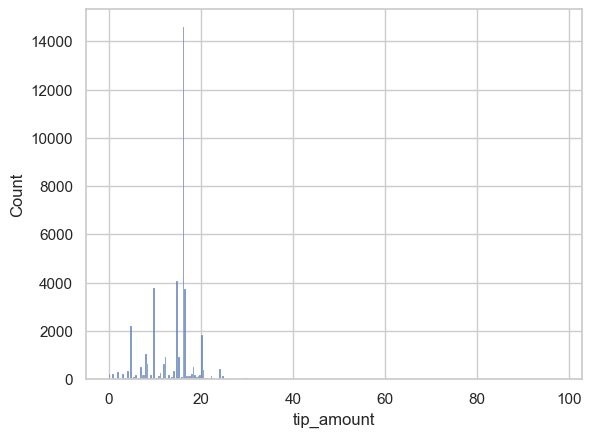

In [ ]:
# SECTION 1

taxi = pd.read_csv(TAXI_URL)

taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()

sns.histplot(taxi["tip_amount"])

print((taxi["tip_amount"] < 0).sum())
print((taxi["trip_distance"] == 0).sum())

The shape is described by the rows and columns of the entire dataset, which results in 41202 rows x 13 columns in total. There appears to be no missing values because the report column for non-null shows all 41202 rows. The results showed no negative tips, showing there were no data errors, but 76 zero-distance trips after I added a command to check it. The distribution of tip amount looked multimodal, with multiple distinct peaks rather than one smooth hump, and a small number of trips forming a long tail of high-value outliers. The multimodal distribution would help me consider keeping or removing extreme tip values that may distort the model before training a regression model.

In [ ]:
taxi = taxi[(taxi["trip_distance"] > 0) & (taxi["fare_amount"] > 0)]
taxi = taxi[taxi["tip_amount"] >= 0]

# Feature engineering
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharges"] = (
    taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]
)

# Encode categoricals
categorical_cols = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
taxi = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

# Scale numeric features (scaler fit on TRAIN only — see Part 1.3)
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges",
]
scaler = StandardScaler()

Since there were no missing values, I focused on filtering the bad data (76 zero distance trips), that is trip distance that is less than or equal to 0. And any fare amount less than or equal to zero means there was no completed trip and was removed. I chose to filter these rows rather than impute them because there's no reliable way to guess what a trip's true distance or fare should have been. I feature engineered fare per mile, which captures efficiency/rate rather than raw distance, and total surcharges, which captures 3 small separate fee columns, and none of the features were derived from tip amount, so there's no risk of leaking the target into the model. I chose the StandardScaler method because it transforms each feature to have a mean of 0 and standard deviation of 1, which overall helps normalization and prevents prioritization of one feature over another.

In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Separate features (X) and target (y = tip_amount)
X = taxi.drop(columns=["tip_amount"])
y = taxi["tip_amount"]

# Split into train / validation / test (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

# Fit scaler on TRAINING set only, then transform train, val, and test
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

For my train data i allocated 60%, for validation data and test data i split the remainder 40% into two halves that is 50 : 50 resulting in a final 60:20:20 ratio.  As the test set does the final unbiased check , the separate validation set is going to be responsible for performance measure while we're comparing models by going back to check and tune against it repeatedly without contaminating the final result. The scaler must fit to prevent leaking data from the validation or test into training. This way the model would behave well and be honest in real world.

Linear Regression
Train: RMSE=4.8173, R2=0.0488
Validation: RMSE=4.7795, R2=0.0689
Test: RMSE=5.2236, R2=0.0402

Random Forest
Train: RMSE=2.8247, R2=0.6730
Validation: RMSE=5.4389, R2=-0.2057
Test: RMSE=5.8140, R2=-0.1890



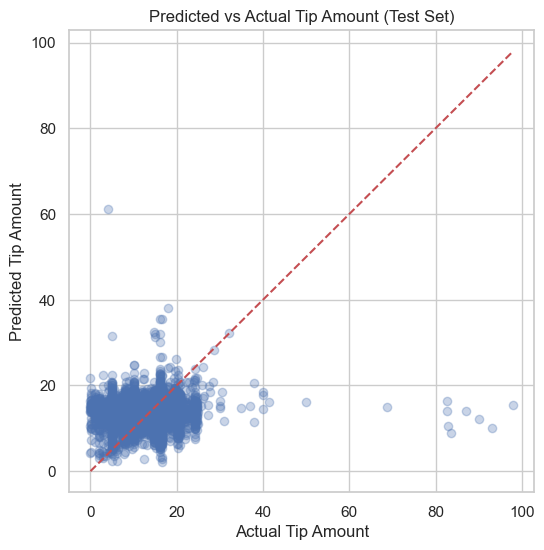

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train a simple model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Train a more flexible model
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Predict on train, validation, and test sets
for name, model in [("Linear Regression", lr), ("Random Forest", rf)]:
    print(name)
    for split_name, X_split, y_split in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        y_pred = model.predict(X_split)
        rmse = mean_squared_error(y_split, y_pred) ** 0.5
        r2 = r2_score(y_split, y_pred)
        print(f"{split_name}: RMSE={rmse:.4f}, R2={r2:.4f}")
    print()

# Plot predicted vs actual tip for the test set
y_test_pred = rf.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tip Amount (Test Set)")
plt.show()

On validation, Linear Regression recorded RMSE = 4.7795 and R² = 0.0689 while Random Forest recorded RMSE = 5.4389 and R² = -0.2057. A lower RMSE and positive R² from Linear Regression makes it more effective than Random Forest. This simply means that on unseen data, Random Forest performs worse than just predicting the average tip for every trip. No hyperparameters were explicitly tuned. Looking at train vs validation vs test, Random Forest is clearly overfitting: Train R² = 0.6730 dropped sharply to Validation R² = -0.2057 and Test R² = -0.1890, meaning the model memorized training data that doesn't generalize. Linear Regression is underfitting instead its R² stayed low and close across all three sets (Train R² = 0.0488, Validation R² = 0.0689, Test R² = 0.0402), meaning the model didn't capture much signal even on the data it was trained on. To reduce Random Forest's overfitting, I would limit the max tree depth to a lower value (e.g. max_depth=5 or 10) instead of leaving it unlimited, increase min_samples_leaf to a higher sample number, and consider reducing n_estimators or using cross-validation to tune these settings.

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

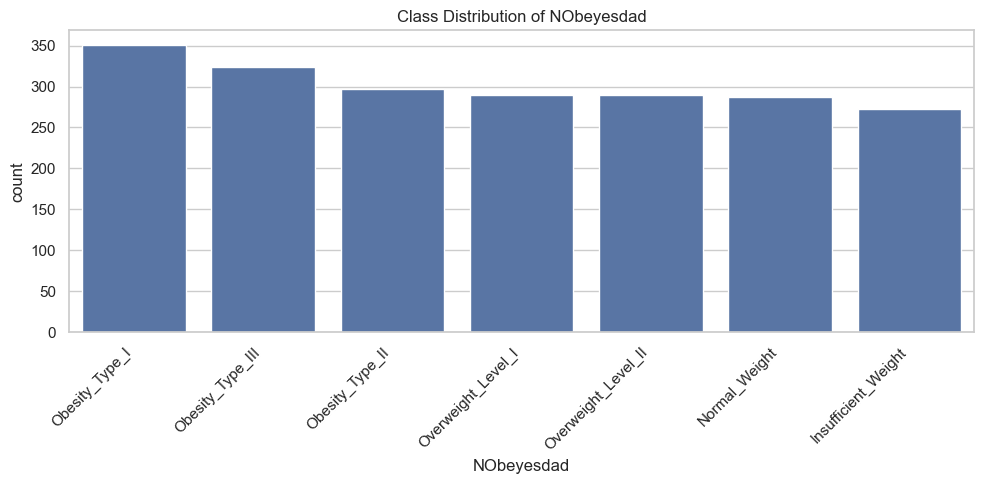

In [ ]:
# SECTION 2

obesity = pd.read_csv(OBESITY_URL)

obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()

obesity["NObeyesdad"].value_counts()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=obesity, x="NObeyesdad", order=obesity["NObeyesdad"].value_counts().index
)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution of NObeyesdad")
plt.tight_layout()
plt.show()

The results show 2111 rows and 17 columns total (16 features + the target NObeyesdad). There are nine categorical columns which include gender, family history with overweight, favc, caec, smoke, scc, calc, mtrans and NObeyesdad. The 8 numeric columns are age, height, weight, fcvc, ncp, ch2o, faf, and tue. The chart shows a fairly balanced distribution, not perfectly equal but nowhere near severe imbalance. Imbalance is problematic here because once a target class is high it may cause a model to rack up high accuracy just by favoring the majority class without really learning to distinguish the minority ones.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

# Encode binary yes/no columns
binary_cols = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_cols:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

# Ordinal encoding for CAEC and CALC (they have a natural low-to-high order)
caec_order = ["no", "Sometimes", "Frequently", "Always"]
calc_order = ["no", "Sometimes", "Frequently", "Always"]

ordinal_encoder = OrdinalEncoder(categories=[caec_order, calc_order])
obesity[["CAEC", "CALC"]] = ordinal_encoder.fit_transform(obesity[["CAEC", "CALC"]])

# One-hot encoding for nominal columns (Gender, MTRANS have no natural order)
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)

# Engineer BMI feature
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Encode the target into integer class labels
target_encoder = LabelEncoder()
obesity["NObeyesdad_encoded"] = target_encoder.fit_transform(obesity["NObeyesdad"])

Yes, I feature engineered BMI = Weight / Height *2, but I question whether it's fair to include. Since obesity categories are typically defined using BMI thresholds in the first place, including BMI as a feature is close to giving the model the answer directly, rather than testing whether lifestyle and habit patterns (diet, exercise, smoking, etc.) can predict obesity level. This risks making the task artificially easy and undermines the more interesting question the other features are meant to test.

In [ ]:
# Separate X (features) and y (encoded NObeyesdad)
X = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y = obesity["NObeyesdad_encoded"]

# Split into train / validation / test using stratify=y
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

# Fit the scaler on the training set only, then transform train / val / test
numeric_cols_obesity = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "BMI",
]

scaler_obesity = StandardScaler()
X_train[numeric_cols_obesity] = scaler_obesity.fit_transform(
    X_train[numeric_cols_obesity]
)
X_val[numeric_cols_obesity] = scaler_obesity.transform(X_val[numeric_cols_obesity])
X_test[numeric_cols_obesity] = scaler_obesity.transform(X_test[numeric_cols_obesity])

For my train data I allocated 60%, for validation data and test data I split the remainder 40% into two halves, that is 50:50, resulting in a final 60:20:20 ratio. Stratify tells train_test_split to preserve the same proportion of each class in every split rather than splitting randomly. This matters especially here since classes range from about 270 to 350 samples, so an unlucky random split could meaningfully skew one or more of the smaller classes. Without stratification, a random split could easily put more of one class into train and less into validation/test, or vice versa. What could go wrong is that a random split may, by chance, end up with very few examples of a minority class in the validation or test set or, worse, a class could be barely represented (or even missing entirely) from the training set, meaning the model would never learn to recognize it at all, regardless of how it's evaluated. If a class is underrepresented in validation, we can't measure the model's performance on it accurately.

Logistic Regression
Train: Accuracy=0.9186, Macro-F1=0.9154
Validation: Accuracy=0.8934, Macro-F1=0.8919
Test: Accuracy=0.8913, Macro-F1=0.8859

Random Forest
Train: Accuracy=1.0000, Macro-F1=1.0000
Validation: Accuracy=0.9905, Macro-F1=0.9901
Test: Accuracy=0.9764, Macro-F1=0.9759

                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.89      1.00      0.94        58
     Obesity_Type_I       0.97      1.00      0.99        70
    Obesity_Type_II       1.00      0.98      0.99        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       1.00      0.93      0.96        58
Overweight_Level_II       1.00      0.97      0.98        58

           accuracy                           0.98       423
          macro avg       0.98      0.97      0.98       423
       weighted avg       0.98      0.98      0.98       423



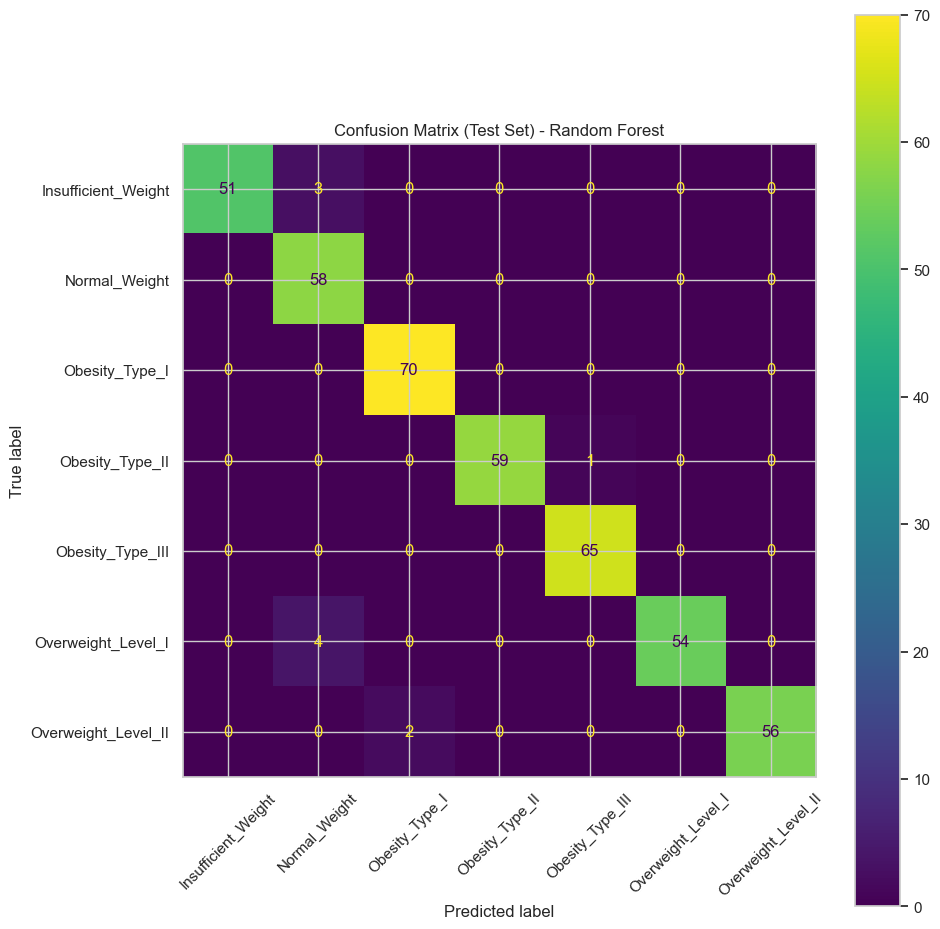

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Train a simple classifier
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# Train a more flexible classifier
rf_clf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)

# Predict on train, validation, and test; report accuracy and macro-F1
for name, model in [("Logistic Regression", log_reg), ("Random Forest", rf_clf)]:
    print(name)
    for split_name, X_split, y_split in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        y_pred = model.predict(X_split)
        acc = accuracy_score(y_split, y_pred)
        macro_f1 = f1_score(y_split, y_pred, average="macro")
        print(f"{split_name}: Accuracy={acc:.4f}, Macro-F1={macro_f1:.4f}")
    print()

# Classification report for test set (best model)
print(
    classification_report(
        y_test, rf_clf.predict(X_test), target_names=target_encoder.classes_
    )
)

# Confusion matrix for test set
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_clf.predict(X_test),
    display_labels=target_encoder.classes_,
    xticks_rotation=45,
    ax=ax,
)
plt.title("Confusion Matrix (Test Set) - Random Forest")
plt.tight_layout()
plt.show()

From the results, Random Forest clearly outperforms Logistic Regression on every metric across every split. So I chose Random Forest as the classifier. It is able to capture non-linear relationships and feature interactions that a linear model can't, which likely matters here given things like BMI, weight, and habits interacting in complex ways to determine obesity category. Random Forest's train accuracy was perfect, which indicates overfitting, but looking at validation and test accuracy, it still stays as high as 0.9905 and 0.9764, with macro-F1 staying almost perfect too. Despite perfect train performance, there's only a small drop-off to validation/test, not a total collapse like with the taxi Random Forest. So while the perfect train score looks like classic overfitting, the fact that validation/test performance stays strong and close to train tells a different story than just overfitting. For Logistic Regression, train, validation, and test had no huge gap either, which clearly looked like a well-fitted model with consistent performance across the three sets, just at a lower ceiling than Random Forest. Looking at the confusion matrix, the misclassifications are: Insufficient_Weight (3 predicted as Normal_Weight), Overweight_Level_I (4 predicted as Normal_Weight), Overweight_Level_II (2 predicted as Normal_Weight), and Obesity_Type_II (1 predicted as Obesity_Type_III). All of these confusions happen between adjacent weight categories rather than distant ones. This makes sense because obesity levels sit on a continuous underlying spectrum, so the boundary between neighboring categories is naturally blurry, while categories far apart on that spectrum have very different feature values and are rarely confused with each other.

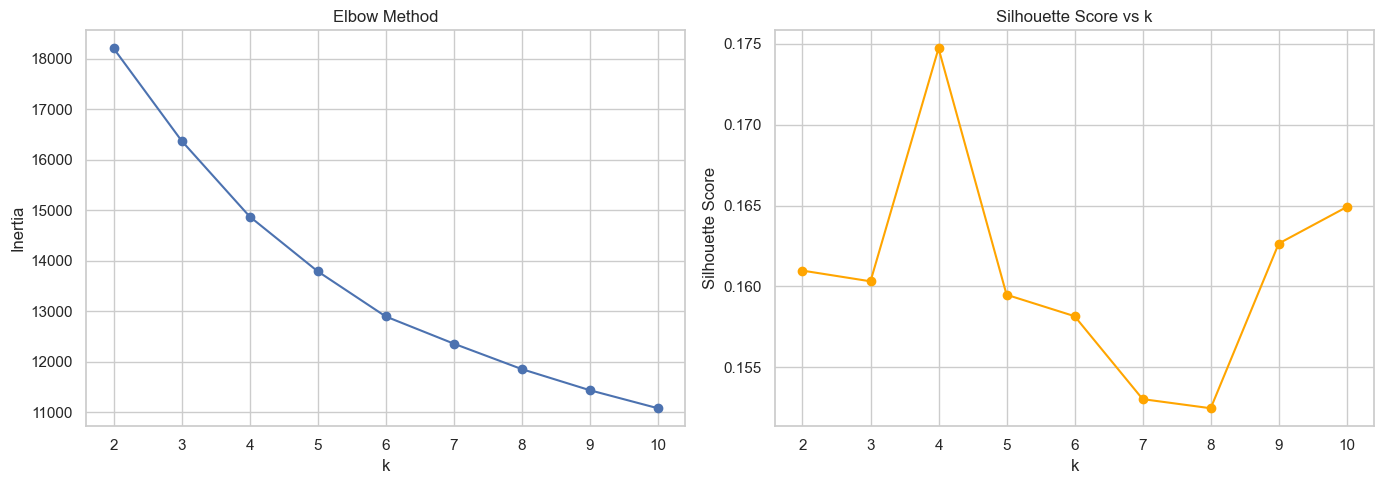

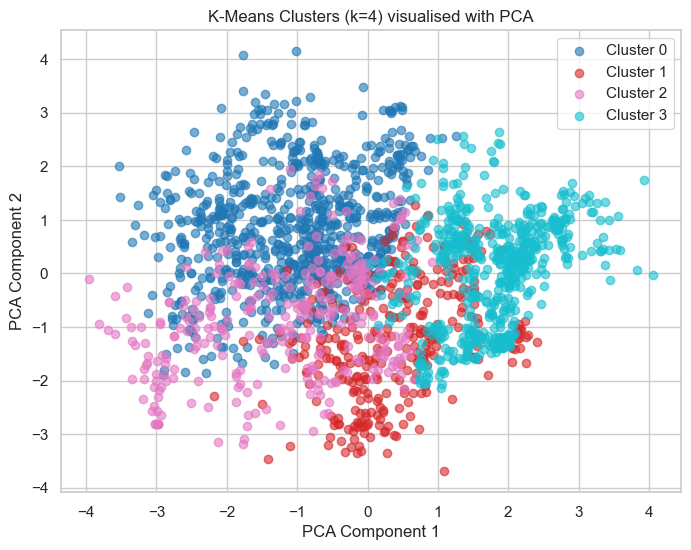

In [ ]:
# SECTION 3
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use ONLY the scaled obesity features (no target)
X_cluster = pd.concat([X_train, X_val, X_test])

# Choose k with the Elbow method and silhouette score
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="orange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

# Fit KMeans with chosen k
k_chosen = 4
kmeans = KMeans(n_clusters=k_chosen, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

# Visualise the clusters in 2D with PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, k_chosen))

for cluster_num in range(k_chosen):
    mask = cluster_labels == cluster_num
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        color=colors[cluster_num],
        alpha=0.6,
        label=f"Cluster {cluster_num}",
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"K-Means Clusters (k={k_chosen}) visualised with PCA")
plt.legend()
plt.show()

In [ ]:
# How well do the clusters line up with the TRUE obesity levels?
true_labels = obesity.loc[X_cluster.index, "NObeyesdad"]

crosstab = pd.crosstab(cluster_labels, true_labels)
crosstab

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
row_0,,,,,,,
0,218,219,99,1,0,156,138
1,2,16,98,59,0,54,99
2,52,52,64,28,0,80,50
3,0,0,90,209,324,0,3


The silhouette score peaked sharply at k=4 clearly higher than any other k value tested. The elbow plot supported this too as inertia dropped steeply from k=2 to k=4 then flattened out noticeably from k= 4 onwards consistent with 4 being the natural bend point. I chose k = 4 even though i had 7 true classes this means k-means can't create a one to one mapping but rather it will group multiple true categories together. This captures the broad , low-to-high weight spectrum (Cluster 3 = heaviest, Cluster 0 = lighter end), but it can't resolve the finer distinctions between neighboring categories(eg. separating overweight level I from overweight level II or Insufficient from Normal) the way the original 7-class labeling does. Clustering could be used to flag a high risk group for targeted intervention without needing a full clinical diagnosis for everyone. It could also help prioritize limited healthcare resources/screening towards clusters that look highest risk. They help to provide a rough low cost pre-screening layer before formal diagnosis especially in large populations or resource limited settings.

#SECTION 4
Random Forest classifier had NObeyesdad labels during training, learning to draw decision boundaries specifically tuned to separate all 7 distinct categories, which is why it could hit 97.64% test accuracy and cleanly distinguish even neighboring classes like Overweight_Level_I vs II. Meanwhile, K-Means never had labels it could only find structure based on distance or density in the feature space itself, without needing any labeled data at all. It found 4 natural groupings, not 7, and results from my crosstab showed it could roughly capture the broad "how heavy" spectrum (Cluster 3 = severe obesity, cleanly isolated) but couldn't resolve finer distinctions the way Random Forest could.
For regression, I evaluated using RMSE and R², which measure how far off a numeric prediction was being off by $2 is a smaller error than being off by $20, so there's a graded sense of wrongness. For classification, I used accuracy, macro-F1, and a confusion matrix instead, since predictions are either the exact right category or not there's no partial credit for being "close." Classification also needed macro-F1 specifically because of the class balance concern, whereas regression didn't need that at all, since there's no such thing as a majority class for a continuous target.
From comparison, the taxi Random Forest regression had by far the worst train-vs-test gap, going from Train R²=0.6730 to Test R²=-0.1890, meaning it performed worse than simply predicting the average tip. To address this, I would limit the tree depth (e.g. max_depth=5 or 10) to reduce the model's ability to memorize noise in the training data, which should shrink the train-test gap by forcing it to learn more general patterns.